# checking the implicit method is correct or not

ValueError: The variable 'uk' is None. Please ensure it is initialized properly before calling the function.

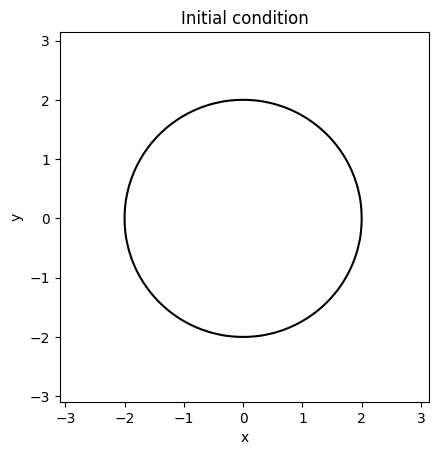

In [ ]:

import jax
import numpy as np
import jax.random as random
import jax.numpy as jnp
import jax.numpy.fft as jfft
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure
from numpy import sqrt
from numpy import round
from matplotlib import pyplot as plt
from matplotlib import contour
from jax.numpy.fft import fft2, ifft2
from jax.numpy.fft import fftn, ifftn
from numpy import real
from jax.example_libraries.stax import serial, Gelu
from jax.example_libraries.optimizers import optimizer, make_schedule
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter


def allen_cahn_equation_implicit(uk, pp2, qq2, dt, eps, Nt, tol=1e-6, max_iter=50):
    """
    Implicit solver for the Allen-Cahn equation using Newton's method.

    Parameters:
    uk       : array  - Initial condition in real space.
    pp2, qq2 : array  - Fourier mode coefficients.
    dt       : float  - Time step size.
    eps      : float  - Small regularization parameter.
    Nt       : int    - Number of time steps.
    tol      : float  - Convergence tolerance for Newton's method.
    max_iter : int    - Maximum iterations for Newton's method.

    Returns:
    samples_timesteps : array - Solution snapshots at every 1000 steps.
    """

    cahn = eps**2
    samples_timesteps = []

    for iter in range(Nt + 1):
        uk = jnp.real(uk)

        # Compute denominator in Fourier space (same as explicit)
        denominator = cahn + dt * (2 + cahn * (pp2 + qq2))

        # Initial guess for Newton's method (take the previous value)
        uk_next = uk

        # Newton's method loop
        for _ in range(max_iter):
            f_uk = uk_new**3 - 3 * uk_new  # Nonlinear function f(u)
            df_uk = 3 * uk_new**2 - 3       # Derivative f'(u)

            # Compute g(u) for Newton’s iteration
            g_uk = uk_new - (cahn * uk - dt * f_uk) / denominator

            # Compute g'(u) (Jacobian for Newton update)
            g_prime_uk = 1 - (-dt * df_uk) / denominator

            # Newton update step
            uk_next = uk_new - g_uk / g_prime_uk

            # Check convergence
            if jnp.max(jnp.abs(uk_next - uk_new)) < tol:
                break

            uk_new = uk_next

        # Compute Fourier Transform after solving Newton step
        s_hat = jnp.fft.fft2(uk_new)
        v_hat = s_hat / denominator
        uk = jnp.fft.ifft2(v_hat)  # Inverse FFT

    #     if iter % 2000 == 0:
    #         samples_timesteps.append(jnp.real(uk))
    #         print(f'sample {iter} completed')

    # return jnp.array(samples_timesteps)







# difinning the no of grid points in x, y and z
Nx = 128 # number of grid points in x be positive even integer number
Ny = 128 # number of grid points in y be positive even integer number


# Define the parameters of the Allen-Cahn equation in 2d
Lx = 2.0 * jnp.pi #length of the domain in x
Ly = 2.0 * jnp.pi #length of the domain in y
hx = Lx / Nx #spatial step size in coordinate x
hy = Ly / Ny #spatial step size in coordinate y
dt = 0.0001 #time step size
T = 4 #final time
Nt = int(jnp.round(T/dt)) #number of time steps
ns = Nt / 10 #number of snapshots

# Define the grid points in x and y direction
def x_gridpoint(Nx, Lx, hx):
    x = jnp.linspace(-0.5*Lx+hx,0.5*Lx,Nx)
    return x
x = x_gridpoint(Nx, Lx, hx) #number of grid points in x direction and step size and limitation on x  axis
def y_gridpoint(Ny, Ly, hy):
    y = jnp.linspace(-0.5*Ly+hy,0.5*Ly,Ny)
    return y
y = y_gridpoint(Ny, Ly, hy) #number of grid points in y direction and step size and limitation on y  axis 

# creating meshgrid in x and y direction
xx,yy = jnp.meshgrid(x,y) #creating meshgrid in x and y direction 

# defining parameters for the Allen-Cahn equation
#It determines the scale of the transition region (interface width) between phases. its the width of the interface, smaller epsillon refer to the sharp transition

epsillon = 0.05 #small parameter # interface thickness in the Allen-Cahn equation 
cahn = epsillon**2 #cahn number  

# initial condition of allen cahn equation
uk =jnp.tanh((2 -sqrt(xx**2 + yy**2)) / (sqrt(2) *epsillon)) #initial condition of allen cahn equation
# theta = jnp.arctan(y/x)
# u =jnp.tanh((1.7 - 1.2 * jnp.cos(6*theta) - sqrt(xx**2 + yy**2)) / (sqrt(2) *epsillon))


# defining the wavenumber in x and y direction , which is in fourier space
p = jnp.concatenate([2 * jnp.pi / Lx * jnp.arange(0, Nx//2), 2 * jnp.pi / Lx * jnp.arange(-Nx//2  , 0)]) # wavenumber in x direction
q = jnp.concatenate([2 * jnp.pi / Ly * jnp.arange(0, Ny//2), 2 * jnp.pi / Ly * jnp.arange(-Ny//2 , 0)])


# square of wavenumber in x and y direction
p2 = p**2 # square of wavenumber in x direction
q2 = q**2 # square of wavenumber in y direction

# creating meshgrid in x and y direction for square of wavenumber
pp2, qq2 = jnp.meshgrid(p2, q2)
#print(pp2.shape) # creating meshgrid in x and y direction for square of wavenumber


# # plotting the initial condition of the Allen-Cahn equation


#this figure code is pervious code 
figure1 = plt.figure()
plt.contour(x, y, jnp.real(uk.T), [0], colors = 'black')
plt.gca().set_aspect('equal', adjustable='box') 
plt.title('Initial condition')
plt.xlabel('x')
plt.ylabel('y')
# plt.show()


# # providing the range of iteration

for iter in range(1, Nt):
    # u = jnp.real(uk)
    # # print(f'real space u ko size ={u.shape}')
    # # Transforming the solution to the discrete Fourier space
    # s_hat = jfft.fft2(cahn * u - dt * (u**3 - 3 * u)) # us is the real space
    # # print(f's_hat ko size = {s_hat.shape}')
    # v_hat = s_hat / (cahn + dt * (2 + cahn * (pp2 + qq2)))  # Allen-Cahn equation
    # uk = jfft.ifft2(v_hat)  # u_k+1 result
    # # print(f'inverse u ko size = {u.shape}')
    if uk is not None:
        uk = allen_cahn_equation_implicit(uk, pp2, qq2, dt, epsillon, Nt)
    else:
        raise ValueError("The variable 'uk' is None. Please ensure it is initialized properly before calling the function.")

    if iter == 2000:
        plt.contour(x, y, jnp.real(uk.T), [0], colors='red')
        plt.gca().set_aspect('equal', adjustable='box')
        
    if iter == 4000:
        plt.contour(x, y, jnp.real(uk.T), [0], colors='green' )
        plt.gca().set_aspect('equal', adjustable='box')
    
    if iter == 10000:
        plt.contour(x, y, jnp.real(uk.T), [0], colors='blue')
        plt.gca().set_aspect('equal', adjustable='box')

    if iter == 20000:
        plt.contour(x, y, jnp.real(uk.T), [0], colors='red')
        plt.gca().set_aspect('equal', adjustable='box')
    

    # if iter % ns == 0:
    #     plt.contour(x, y, jnp.real(uk.T), [0], colors='red')
    #     plt.gca().set_aspect('equal', adjustable='box') 
    #     # np.save("initial_condition.npy", uk)
    #     # np.save("final_output.npy", jnp.real(u))


# from this line to the print initial and final condition saved as for data saved purpose
# Save the final output
  # Save in .txt format (readable)

plt.title('Numerical Solutions after iteration ' + str(Nt))
plt.show()


# # this is previous code   
# plt.title('Numerical Solutions after iteration ' + str(Nt))
# plt.show()

# Notify user of saved files
# print("Initial and final conditions saved as:")
# print("- 'initial_condition.npy' and 'initial_condition.txt'")
# print("- 'final_output.npy' and 'final_output.txt'")
# print(f"Current u_iter shape: {u.shape}")
# print(f"Plotting value: {jnp.real(uk.T).shape}")






# data generation on implicit method 

In [ ]:

import jax
import numpy as np
import jax.random as random
import jax.numpy as jnp
import jax.numpy.fft as jfft
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure
from numpy import sqrt
from numpy import round
from matplotlib import pyplot as plt
from matplotlib import contour
from jax.numpy.fft import fft2, ifft2
from jax.numpy.fft import fftn, ifftn
from numpy import real
from jax.example_libraries.stax import serial, Gelu
from jax.example_libraries.optimizers import optimizer, make_schedule
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter
from jax.numpy.fft import fft2, ifft2
import os 
from functools import partial
import jax.numpy as jnp
import jax.scipy.fft as jfft
from jax import jit

# @partial(jit, static_argnums=(0,))
def allen_cahn_equation_implicit(uk, pp2, qq2, dt, eps, Nt, tol=1e-6, max_iter=50):
    """
    Implicit solver for the Allen-Cahn equation using Newton's method.

    Parameters:
    uk       : array  - Initial condition in real space.
    pp2, qq2 : array  - Fourier mode coefficients.
    dt       : float  - Time step size.
    eps      : float  - Small regularization parameter.
    Nt       : int    - Number of time steps.
    tol      : float  - Convergence tolerance for Newton's method.
    max_iter : int    - Maximum iterations for Newton's method.

    Returns:
    samples_timesteps : array - Solution snapshots at every 1000 steps.
    """

    cahn = eps**2
    samples_timesteps = []

    for iter in range(Nt + 1):
        uk = jnp.real(uk)

        # Compute denominator in Fourier space (same as explicit)
        denominator = cahn + dt * (2 + cahn * (pp2 + qq2))

        # Initial guess for Newton's method (take the previous value)
        uk_new = uk

        # Newton's method loop
        for _ in range(max_iter):
            f_uk = uk_new**3 - 3 * uk_new  # Nonlinear function f(u)
            df_uk = 3 * uk_new**2 - 3       # Derivative f'(u)

            # Compute g(u) for Newton’s iteration
            g_uk = uk_new - (cahn * uk - dt * f_uk) / denominator

            # Compute g'(u) (Jacobian for Newton update)
            g_prime_uk = 1 - (-dt * df_uk) / denominator

            # Newton update step
            uk_next = uk_new - g_uk / g_prime_uk

            # Check convergence
            if jnp.max(jnp.abs(uk_next - uk_new)) < tol:
                break

            uk_new = uk_next

        # Compute Fourier Transform after solving Newton step
        s_hat = jnp.fft.fft2(uk_new)
        v_hat = s_hat / denominator
        uk = jnp.fft.ifft2(v_hat)  # Inverse FFT

        if iter % 2000 == 0:
            samples_timesteps.append(jnp.real(uk))
            print(f'sample {iter} completed')

    return jnp.array(samples_timesteps)







# difinning the no of grid points in x, y and z
Nx = 28 # number of grid points in x be positive even integer number
Ny = 28 # number of grid points in y be positive even integer number



# Define the parameters of the Allen-Cahn equation in 2d
Lx = 2.0 * jnp.pi #length of the domain in x
Ly = 2.0 * jnp.pi #length of the domain in y
hx = Lx / Nx #spatial step size in coordinate x
hy = Ly / Ny #spatial step size in coordinate y
dt = 0.0001 #time step size increase the time step size to 0.01(10times bigger than explcit method)
T = 4 #final time
Nt = int(jnp.round(T/dt)) #number of time steps
ns = Nt / 10 #number of snapshots

# Define the grid points in x and y direction
def x_gridpoint(Nx, Lx, hx):
    x = jnp.linspace(-0.5*Lx+hx,0.5*Lx,Nx)
    return x
x = x_gridpoint(Nx, Lx, hx) #number of grid points in x direction and step size and limitation on x  axis
def y_gridpoint(Ny, Ly, hy):
    y = jnp.linspace(-0.5*Ly+hy,0.5*Ly,Ny)
    return y
y = y_gridpoint(Ny, Ly, hy) #number of grid points in y direction and step size and limitation on y  axis 

# creating meshgrid in x and y direction
xx,yy = jnp.meshgrid(x,y) #creating meshgrid in x and y direction 

epsillon = 0.5 #small parameter # interface thickness in the Allen-Cahn equation 
cahn = epsillon**2 #cahn number  

# theta = jnp.arctan2(yy, xx)
#   # or another appropriate value
# uk = jnp.tanh((1.7 + 1.2 * np.cos(6 * theta)) - jnp.sqrt(xx**2 + yy**2) / (jnp.sqrt(2) * epsillon))
# data = np.load('../data_generation_checking/phasefield2d_data_28x28_10k.npy')
# # data = jnp.real(uk)
# # # Select 1,000 random samples
# key = jax.random.PRNGKey(0)  # Random seed for reproducibility
# idx = jax.random.choice(key, data.shape[0], shape=(10,), replace=False)  # Random 1k indices
# input_samples = data[idx]  # Shape: (1000, Nx, Ny)
# input_samples = data
# print(f'uk ko shape:{uk.shape}')

uk =jnp.tanh((2 -sqrt(xx**2 + yy**2)) / (sqrt(2) *epsillon)) 
data = jnp.real(uk)
input_samples = data    


# defining the wavenumber in x and y direction , which is in fourier space
p = jnp.concatenate([2 * jnp.pi / Lx * jnp.arange(0, Nx//2), 2 * jnp.pi / Lx * jnp.arange(-Nx//2  , 0)]) # wavenumber in x direction
q = jnp.concatenate([2 * jnp.pi / Ly * jnp.arange(0, Ny//2), 2 * jnp.pi / Ly * jnp.arange(-Ny//2 , 0)])


# square of wavenumber in x and y direction
p2 = p**2 # square of wavenumber in x direction
q2 = q**2 # square of wavenumber in y direction

# creating meshgrid in x and y direction for square of wavenumber
pp2, qq2 = jnp.meshgrid(p2, q2)


input_samples= input_samples.reshape(-1, Nx , Ny)
print(f'input_samples ko shape:{input_samples.shape}')

samples = []

# this for to see the how many samples are printed 
for i, uk in enumerate (input_samples):
    print(f'sample {i} started')

# for uk in input_samples:
   
    ac_input = allen_cahn_equation_implicit(uk, pp2, qq2, dt, epsillon, Nt)
# print(f'shape of ac_input:{ac_input.shape}')
    samples.append(ac_input)
    
samples = jnp.array(samples)
# print(f'samples ko shape:{samples.shape}')
      

# Specify the directory where y want to save the data
save_dir = './data_driven/data/implicit'

    # Ensure the directory exists, create it if not
os.makedirs(save_dir, exist_ok=True)

#saving the data 
# Save the training and testing data
# print("Saving training data to u_train.npy...")
np.save(os.path.join(save_dir, "driven_data_28x28_circle_input_samples_21timestep_every2kiter_implicit_circle.npy"), np.array(input_samples))
np.save(os.path.join(save_dir, "driven_data_28x28_circle_21timestep_every2kiter_implicit_circle.npy"), np.array(samples))

# loaded the generated data
loaded_input_samples = np.load(os.path.join(save_dir, "driven_data_28x28_circle_input_samples_21timestep_every2kiter_implicit_circle.npy"))
print(f'loaded_input_samples ko shape:{loaded_input_samples.shape}')

loaded_samples = np.load(os.path.join(save_dir, "driven_data_28x28_circle_21timestep_every2kiter_implicit_circle.npy"))
print(f'loaded_samples ko shape:{loaded_samples.shape}')

input_samples ko shape:(1, 28, 28)
sample 0 started
sample 0 completed
sample 2000 completed
sample 4000 completed
sample 6000 completed
sample 8000 completed
sample 10000 completed
sample 12000 completed
sample 14000 completed
sample 16000 completed
sample 18000 completed
sample 20000 completed
sample 22000 completed
sample 24000 completed
sample 26000 completed
sample 28000 completed
sample 30000 completed
sample 32000 completed
sample 34000 completed
sample 36000 completed
sample 38000 completed
sample 40000 completed
loaded_input_samples ko shape:(1, 28, 28)
loaded_samples ko shape:(1, 21, 28, 28)


# visulized the generated data

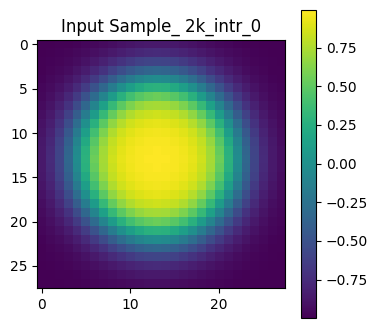

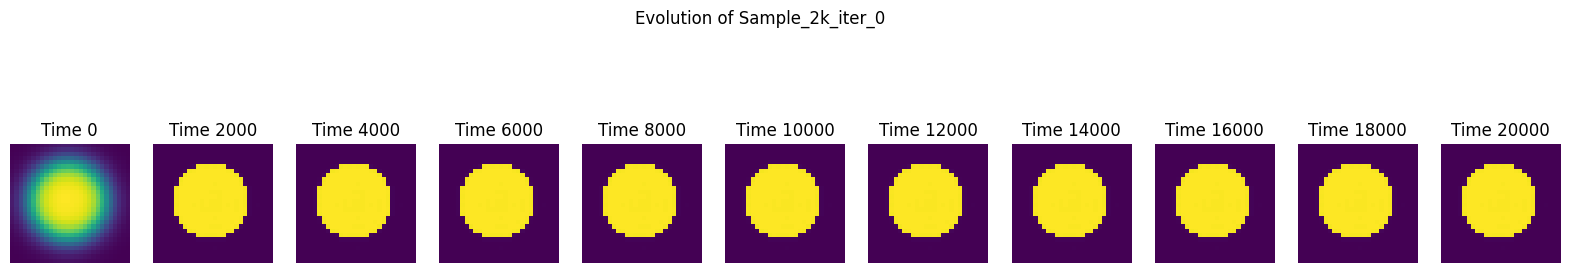

In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt

save_dir = './data_driven'

# Choose a sample index
sample_idx = 0  # Ensure this is within the bounds of loaded_input_samples

# Define the directory
plot_save_dir = os.path.join(save_dir,  "data_driven_plot/implicit")

# Create the directory if it doesn't exist
os.makedirs(plot_save_dir, exist_ok=True)


# Plot input data
plt.figure(figsize=(4, 4))
plt.imshow(loaded_input_samples[sample_idx], cmap='viridis')
plt.colorbar()
plt.title(f'Input Sample_ 2k_intr_{sample_idx}')
plt.savefig(os.path.join(plot_save_dir, f'input_sample_2k_iter_circle_{sample_idx}.png')) 
plt.show()


# Choose a sample index
sample_idx = 0

fig, axes = plt.subplots(1, 11, figsize=(20, 4))  # 11 time steps

for t in range(11):
    axes[t].imshow(loaded_samples[sample_idx, t], cmap='viridis')
    axes[t].set_title(f'Time {t * 2000}')
    axes[t].axis('off')

plt.suptitle(f'Evolution of Sample_2k_iter_{sample_idx}')
plt.savefig(os.path.join(plot_save_dir, f'Evolution_sample_2k_iter_circle_{sample_idx}.png'))
plt.show()